In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from src.core.kernels import compute_kernel

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)

# Kernels and RKHS

A kernel $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is **positive definite** if $\sum_{i,j} c_i c_j \, k(x_i, x_j) \geq 0$ for all finite point sets and coefficient vectors $\mathbf{c}$. Every +ve definite kernel induces a **feature map** $\varphi : \mathcal{X} \to \mathcal{H}$ into a Hilbert space:

$$k(x, y) = \langle \varphi(x), \varphi(y) \rangle_{\mathcal{H}}.$$

The canonical choice is $\varphi(x) = k(\cdot, x)$, the **kernel section** at $x$. This lives in the **reproducing kernel Hilbert space (RKHS)** $\mathcal{H}_k$: the completion of $\operatorname{span}\{k(\cdot, x) : x \in \mathcal{X}\}$ under $\langle k(\cdot, x), k(\cdot, y) \rangle = k(x, y)$.

## Reproducing property

$$f(x) = \langle f, k(\cdot, x) \rangle_{\mathcal{H}_k}$$

Point evaluation is a bounded linear functional. One can find $f(x)$ by projecting onto $k(\cdot, x)$. 

This is what separates RKHS from $L^2$: in $L^2$, functions are equivalence classes, (class of represenative functions that are equal almost everywhere), so pointwise values are undefined. The RKHS is a strictly smaller space where the norm controls pointwise behaviour.

## Regualisation

The RKHS norm penalises complexity. The GP posterior mean minimises

$$\|f\|_{\mathcal{H}_k}^2 + \frac{1}{\lambda} \sum_i (f(x_i) - y_i)^2$$

so the kernel determines what "simple" means.

## Eigendecomposition and smoothness

For a Mercer kernel (continuous, +ve definite, compact domain), the integral operator $T_k f(x) = \int k(x,y) f(y) \, dy$ has a countable eigensystem $\{(\lambda_i, \phi_i)\}$. The feature map becomes

$$\varphi(x) = (\sqrt{\lambda_1}\,\phi_1(x),\; \sqrt{\lambda_2}\,\phi_2(x),\; \ldots) \in \ell^2$$

and the RKHS consists of $f = \sum_i a_i \phi_i$ with $\|f\|_{\mathcal{H}_k}^2 = \sum_i a_i^2 / \lambda_i < \infty$. Eigenvalue decay controls effective dimensionality:
- **Fast decay (RBF: super-exponential):** few directions matter, functions must be very smooth
- **Slow decay (Matérn: polynomial):** more directions contribute, rougher functions admitted

The **Gram matrix** $K_{ij} = k(x_i, x_j)$ is the finite-dim shadow of this structure.

## Gaussian Process

A GP with kernel $k$ is a Gaussian measure $\mu$ on function space whose **Cameron–Martin space** is $\mathcal{H}_k$:

$$\mu(\cdot - h) \ll \mu \iff h \in \mathcal{H}_k$$

$\mu(\cdot - h)$ is the GP translated by $h$. $\nu \ll \mu$ (absolute continuity) means if $\mu(A) = 0$ then $\nu(A) = 0$ for all subsets. So the translated GP and the original agree on which events are impossible, iff $h \in \mathcal{H}_k$. If $h \notin \mathcal{H}_k$, the measures are singular ($\mu(\cdot - h) \perp \mu$: they live on disjoint sets).

Sample paths live outside $\mathcal{H}_k$ a.s., but the posterior mean always lies in it.

## Spectral density

The choice of kernel determines what "smooth" means. Each kernel's RKHS admits a different class of functions, and the RKHS norm penalises different kinds of roughness.

A kernel is **stationary** if it depends only on the displacement $x - y$, not on the absolute positions: $k(x,y) = \psi(x - y)$. This means the kernel extracts the same similarity structure everywhere in the input space. Translating all data points by a constant changes nothing. 

RBF, RQ, and Matérn are all stationary; TPS is not.

For stationary kernels, the Fourier transform $\hat\psi(\omega)$ is the **spectral density** (Bochner's theorem: $\psi$ is +ve definite iff $\hat\psi \geq 0$). Here $\hat\psi$ denotes the (forward) Fourier transform, which decomposes $\psi$ into its frequency components:

$$\hat\psi(\omega) = \int_{\mathbb{R}^d} \psi(\tau) \, e^{-i\omega \cdot \tau} \, d\tau$$

$\hat\psi(\omega)$ measures how much of frequency $\omega$ is present in the kernel. Similarly $\hat f(\omega)$ is the Fourier transform of $f$. The RKHS norm in the frequency domain becomes

$$\|f\|_{\mathcal{H}_k}^2 = \int \frac{|\hat f(\omega)|^2}{\hat\psi(\omega)} \, d\omega$$

The kernel's spectral density acts as a **weighting**: take each frequency component $|\hat f(\omega)|^2$ of $f$ and divide by how much the kernel prefers that frequency $\hat\psi(\omega)$:

- Where $\hat\psi(\omega)$ is large, the penalty is small.
- Where $\hat\psi(\omega)$ decays to zero (high frequencies for smooth kernels), the penalty is large. Components are heavily penalised or excluded entirely.

In terms of function spaces:

- **RBF:** $\hat\psi(\omega) \propto \exp(-\ell^2\|\omega\|^2/2)$ is Gaussian decay. The denominator $1/\hat\psi$ grows super-exponentially, so only functions with Gaussian-decaying Fourier transforms have finite RKHS norm. The RKHS consists of **entire (real-analytic) functions**. This is the smoothest possible choice.

- **Matérn-$\nu$:** $\hat\psi(\omega) \propto (1 + \ell^2\|\omega\|^2)^{-(\nu + d/2)}$ is polynomial decay. The RKHS is norm-equivalent to the **Sobolev space** $H^{\nu+d/2}(\mathbb{R}^d)$, the space of functions with $\nu + d/2$ square-integrable (weak) derivatives. Increasing $\nu$ demands more derivatives, giving finer control over regularity. As $\nu \to \infty$, the Matérn converges to the RBF.

- **Rational Quadratic:** (scale mixture of RBFs). RQ's spectral density is a weighted average of Gaussians with different widths. The RKHS inherits $C^\infty$ smoothness but with a heavier-tailed spectrum: it penalises high-frequency content less than the RBF, better at multi-scale.

### Non-stationary example: TPS

The thin plate spline kernel is **non-stationary** and only **conditionally +ve definite**, so Bochner's theorem does not apply directly. Its native space is the **Beppo Levi space** $BL_2(\mathbb{R}^d)$: functions whose second-order partial derivatives are in $L^2$. The associated seminorm

$$|f|_{BL_2}^2 = \int_{\mathbb{R}^d} \sum_{|\alpha|=2} \binom{2}{\alpha} (D^\alpha f)^2 \, dx$$

is the **thin-plate bending energy** (measures total curvature). This is only a seminorm (polynomials of degree $\leq 1$ have zero bending energy), which is why TPS requires polynomial augmentation or regularisation. The interpolant that minimises this energy is the smoothest surface passing through the data in the sense of minimal curvature.

In [2]:
def kernel_slice_1d(kernel_type, sigma_vals, alpha=None, x_range=(-3, 3), n=300):
    """Eval k(0, x) for a 1D grid, at each sigma value."""
    x = np.linspace(*x_range, n).reshape(-1, 1)
    origin = np.zeros((1, 1))
    results = {}
    for s in sigma_vals:
        sigma = np.array([s])
        K = np.asarray(compute_kernel(kernel_type, origin, x, sigma, alpha=alpha))
        results[s] = K[0]

    return x.ravel(), results


def kernel_matrix_1d(kernel_type, sigma_val, alpha=None, x_range=(-2, 2), n=50):
    """Get the kernel Gram matrix on a 1D grid."""
    x = np.linspace(*x_range, n).reshape(-1, 1)
    sigma = np.array([sigma_val])
    K = np.asarray(compute_kernel(kernel_type, x, x, sigma, alpha=alpha))
    return x.ravel(), K


def plot_slices(x, results, title, ylabel=r"$k(0, x)$"):
    """Plot kernel slices for different parameter values."""
    fig, ax = plt.subplots(figsize=(6, 3.5))
    for label, vals in results.items():
        ax.plot(x, vals, label=label, linewidth=1.5)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    return fig


def plot_heatmap(x, K, title):
    """Plot a kernel matrix heatmap."""
    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(K, extent=[x[0], x[-1], x[-1], x[0]], cmap="viridis")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    return fig

## RBF (Squared Exponential) Kernel

$$k(x, y) = \exp\!\left(-\frac{\|x - y\|_\Sigma^2}{2}\right)$$

where $\|x - y\|_\Sigma^2 = \sum_d (x_d - y_d)^2 / \sigma_d^2$ is the squared Mahalanobis distance.

### Spectral density

The RBF is stationary with $\psi(\tau) = \exp(-\|\tau\|^2/2)$, where $\tau = x - y$. Its Fourier transform is the Gaussian integral:

$$\hat\psi(\omega) = \int_{\mathbb{R}^d} e^{-\|\tau\|^2/2} \, e^{-i\omega\cdot\tau} \, d\tau = (2\pi)^{d/2} \exp\!\left(-\frac{\|\omega\|^2}{2}\right)$$

(completing the square in the exponent). So the spectral density is itself a Gaussian, it decays super-exponentially in frequency.

### Eigendecomposition

On a compact domain (say $[-1,1]$), the eigenfunctions of $T_k$ are **Hermite functions** $\phi_n(x) = H_n(x) e^{-x^2/4}$ (up to normalisation), with eigenvalues

$$\lambda_n \propto \rho^n, \quad \rho < 1$$

decaying geometrically (faster than any polynomial). This means the RKHS is extremely "thin". The weighted norm $\|f\|_{\mathcal{H}_k}^2 = \sum_n a_n^2/\lambda_n$ blows up unless the coefficients $a_n$ decay at least as fast as $\rho^{n/2}$, restricting to real-analytic functions.

### Implications

The RBF kernel assumes the target function is infinitely smooth. If the true function has a discontinuity in derivatives, or any non-analytic feature, the RBF will either oversmooth it or require an unreasonably small length scale $\sigma$ (which introduces precision problems).

**Length scale:** $\sigma$ controls the correlation range. As $\sigma \to 0$, the Gram matrix approaches $I$ (each point is uncorrelated with everything else). As $\sigma \to \infty$, $K \to \mathbf{1}\mathbf{1}^\top$ (all points are perfectly correlated, i.e., the function is constant).

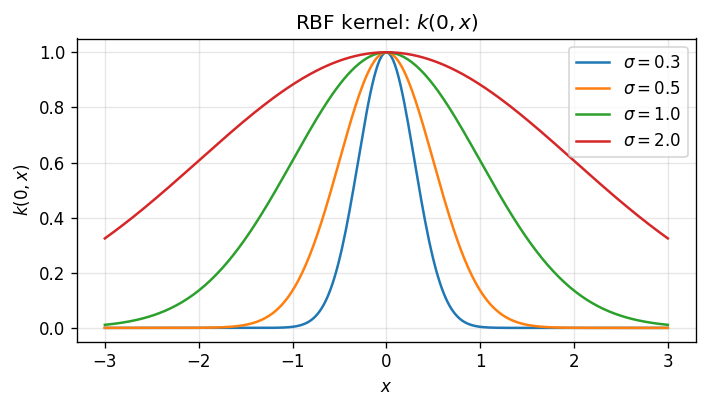

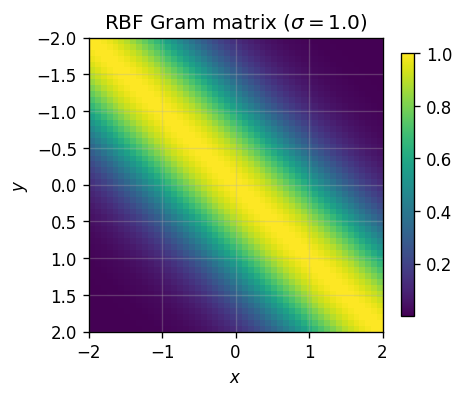

In [3]:
sigmas = [0.3, 0.5, 1.0, 2.0]
x, slices = kernel_slice_1d("RBF", sigmas)
labels = {rf"$\sigma = {s}$": slices[s] for s in sigmas}
plot_slices(x, labels, "RBF kernel: $k(0, x)$")
plt.show()

x_grid, K = kernel_matrix_1d("RBF", sigma_val=1.0)
plot_heatmap(x_grid, K, r"RBF Gram matrix ($\sigma = 1.0$)")
plt.show()

## Rational Quadratic Kernel

$$k(x, y) = \left(1 + \frac{\|x - y\|_\Sigma^2}{2\alpha}\right)^{-\alpha}$$

The RQ kernel is a **scale mixture of RBFs**: it is the **marginal** kernel if you placed a $\text{Gamma}(\alpha, \alpha)$ prior over the squared length scale of an RBF kernel. Each "component" RBF in the mixture has its own length scale, so the RQ kernel naturally models functions with **multi-scale structure**, (local and global trends together).

### Spectral density

The RQ spectral density follows from marginalising the RBF spectral density over the Gamma prior on $\ell^2$:

$$\hat\psi_{\text{RQ}}(\omega) = \int_0^\infty \hat\psi_{\text{RBF}}(\omega; \ell) \; p(\ell^2) \, d(\ell^2) = \int_0^\infty (2\pi\ell^2)^{d/2} e^{-\ell^2\|\omega\|^2/2} \; \frac{\alpha^\alpha}{\Gamma(\alpha)} (\ell^2)^{\alpha-1} e^{-\alpha\ell^2} \, d(\ell^2)$$

Evaluating the integral (it's a Gamma moment-generating function):

$$\hat\psi_{\text{RQ}}(\omega) \propto \left(\alpha + \frac{\|\omega\|^2}{2}\right)^{-(\alpha + d/2)}$$

For large $\alpha$, this concentrates and recovers the Gaussian spectral density of the RBF. For small $\alpha$, the tails are polynomial. The spectral density decays much more slowly than RBF, admitting more high-frequency content.

### Eigendecomposition

Since $\hat\psi_{\text{RQ}}$ has polynomial tails $\sim \|\omega\|^{-(2\alpha+d)}$, the eigenvalues of $T_k$ decay polynomially: $\lambda_n \sim n^{-(2\alpha+d)/d}$. In contrast to the geometric decay of Gaussian RBF, the RQ RKHS is strictly larger. As $\alpha \to \infty$ the decay accelerates toward super-exponential, recovering the RBF.

### The $\alpha$ parameter

- **Small $\alpha$** (e.g. 0.1): heavy-tailed mixture, many length scales contribute. The kernel has fatter tails than RBF so distant points maintain more correlation. The RKHS is correspondingly larger, admitting functions with more heterogeneous frequency content.
- **Big $\alpha$** (e.g. 50): the Gamma distribution concentrates around its mean, and the RQ kernel converges on RBF. The RKHS shrinks toward the analytic functions.

In inf-dim settings, the RQ feature map is a superposition of RBF feature maps at different scales. The RKHS is the intersection $\bigcap_\ell \mathcal{H}_{k_\ell^{\text{RBF}}}$ weighted by the Gamma density, still $C^\infty$, but with less penalty on high-frequency components.

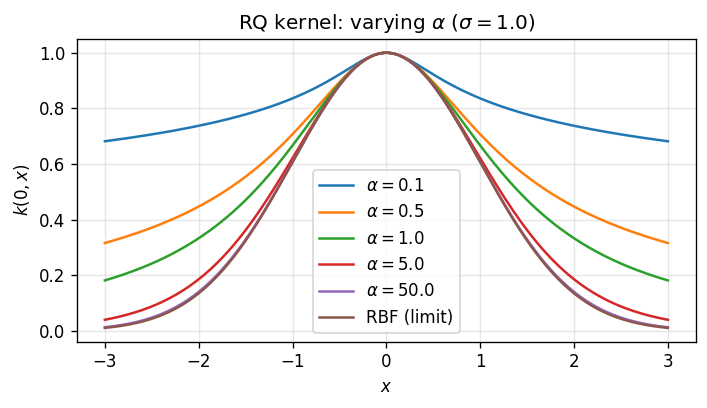

In [4]:
# Fixed sigma, varying alpha, converges to RBF
alphas = [0.1, 0.5, 1.0, 5.0, 50.0]
x = np.linspace(-3, 3, 300).reshape(-1, 1)
origin = np.zeros((1, 1))
sigma = np.array([1.0])

rq_slices = {}
for a in alphas:
    K = np.asarray(compute_kernel("RQ", origin, x, sigma, alpha=a))
    rq_slices[rf"$\alpha = {a}$"] = K[0]

# RBF reference
K_rbf = np.asarray(compute_kernel("RBF", origin, x, sigma))
rq_slices["RBF (limit)"] = K_rbf[0]

plot_slices(x.ravel(), rq_slices, r"RQ kernel: varying $\alpha$ ($\sigma = 1.0$)")
plt.show()

## Matérn Kernel

$$k_\nu(r) = \frac{2^{1-\nu}}{\Gamma(\nu)} \left(\sqrt{2\nu}\,\frac{r}{\ell}\right)^\nu K_\nu\!\left(\sqrt{2\nu}\,\frac{r}{\ell}\right)$$

where $K_\nu$ is the modified Bessel function of the second kind. Closed forms for half-integer $\nu$:

| $\nu$ | $k_\nu(r)$ | Sample path regularity |
|-------|-----------|------------------------|
| $1/2$ | $e^{-r/\ell}$ | Continuous, nowhere differentiable (Ornstein–Uhlenbeck) |
| $3/2$ | $(1 + \sqrt{3}r/\ell)\,e^{-\sqrt{3}r/\ell}$ | Once MS-differentiable |
| $5/2$ | $(1 + \sqrt{5}r/\ell + 5r^2/3\ell^2)\,e^{-\sqrt{5}r/\ell}$ | Twice MS-differentiable |

### Spectral density

The Matérn kernel is the Green's function of the differential operator $(2\nu/\ell^2 - \Delta)^{\nu+d/2}$, where $\Delta$ is the Laplacian. Taking the Fourier transform of both sides (the Laplacian becomes multiplication by $-\|\omega\|^2$):

$$\hat\psi_\nu(\omega) \propto \left(\frac{2\nu}{\ell^2} + \|\omega\|^2\right)^{-(\nu + d/2)}$$

This is a **Student-$t$-like** profile in frequency space. The key feature is polynomial decay: $\hat\psi_\nu(\omega) \sim \|\omega\|^{-(2\nu+d)}$ as $\|\omega\| \to \infty$. Plugging into the RKHS norm $\|f\|^2 = \int |\hat f|^2 / \hat\psi \, d\omega$ gives

$$\|f\|_{\mathcal{H}_k}^2 \propto \int (1 + \|\omega\|^2)^{\nu+d/2} |\hat f(\omega)|^2 \, d\omega = \|f\|_{H^{\nu+d/2}}^2$$

which is exactly the **Sobolev $H^s$ norm** with $s = \nu + d/2$. This is why $\mathcal{H}_{k_\nu} \cong H^{\nu+d/2}(\mathbb{R}^d)$.

### Eigendecomposition

The eigenvalues of $T_k$ inherit the polynomial spectral decay: $\lambda_n \sim n^{-(2\nu+d)/d}$: 

- Where $\nu = 1/2$ in $d=1$, this is $\lambda_n \sim n^{-2}$, we have slow decay, large effective dimension, rough functions admitted
- Where $\nu = 5/2$ in $d=1$, $\lambda_n \sim n^{-6}$, we have faster decay, smoother functions. But always polynomial, never geometric. The Matérn RKHS is always strictly larger than the RBF's.

### Why Matérn matters

Choosing $\nu$ is choosing **how many derivatives** the space demands. High frequencies are penalised polynomially, not exponentially as in RBF. Functions with a finite number of discontinuities can still have finite RKHS norm, which makes the Matérn a more realistic prior for physical data.

As $\nu \to \infty$, the spectral density $(c + \|\omega\|^2)^{-(\nu+d/2)}$ concentrates and in the limit becomes Gaussian, (the Sobolev spaces nest upward and the Matérn converges on RBF).

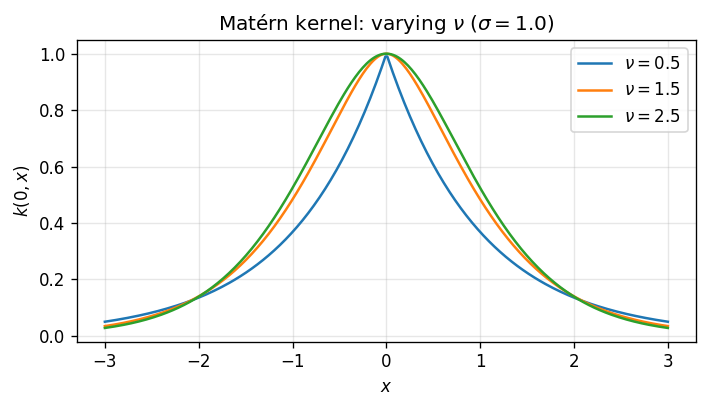

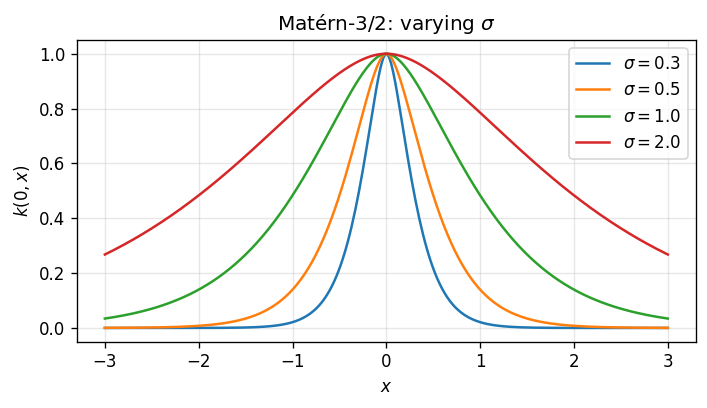

In [5]:
# Overlay nu = 0.5, 1.5, 2.5
nus = [0.5, 1.5, 2.5]
x = np.linspace(-3, 3, 300).reshape(-1, 1)
origin = np.zeros((1, 1))
sigma = np.array([1.0])

matern_slices = {}
for nu in nus:
    K = np.asarray(compute_kernel("MATERN", origin, x, sigma, alpha=nu))
    matern_slices[rf"$\nu = {nu}$"] = K[0]

fig = plot_slices(
    x.ravel(), matern_slices, r"Matérn kernel: varying $\nu$ ($\sigma = 1.0$)"
)
plt.show()

# Vary sigma for nu = 1.5
sigmas = [0.3, 0.5, 1.0, 2.0]
x2, slices2 = kernel_slice_1d("MATERN", sigmas, alpha=1.5)
labels2 = {rf"$\sigma = {s}$": slices2[s] for s in sigmas}
plot_slices(x2, labels2, r"Matérn-3/2: varying $\sigma$")
plt.show()

## Thin Plate Spline (TPS) Kernel

$$k(r) = r^2 \ln r$$

where $r = \|x - y\|_\Sigma$. This is the polyharmonic spline of order 2.

### Why Bochner doesn't apply

TPS is non-stationary ($k(x,y) \neq \psi(x-y)$) and only conditionally +ve definite (CPD), so it has no spectral density in the Bochner sense. However, there is a **generalised Fourier characterisation**. The distributional Fourier transform of the radial basis function $\phi(r) = r^2 \ln r$ in $\mathbb{R}^d$ is

$$\hat\phi(\omega) \propto \|\omega\|^{-(d+4)}$$

as a tempered distribution (not an equivalence class of functions, it's not integrable). This is the characteristic of CPD kernels: the spectral density is singular or non-integrable at the origin, which is why it only defines a positive form on the subspace orthogonal to low-degree polynomials. The singularity at $\omega = 0$ is exactly the polynomial null space.

### Eigendecomposition

Since TPS is not +ve definite, the integral operator $T_k$ is not +ve and has -ve eigenvalues. On a finite point set, the Gram matrix $K$ has both +ve and -ve eigenvalues. The +ve eigenvalues correspond to directions orthogonal to the polynomial space; the -ve ones correspond to the "polynomial directions" where CPD fails.

After projecting out the polynomial null space (degree $\leq 1$), the projected operator is +ve and its eigenvalues decay as $\lambda_n \sim n^{-4/d}$, matching the two derivatives of the Beppo Levi seminorm.

### Beppo Levi

The CPD condition means $\sum_{i,j} c_i c_j \, k(x_i, x_j) \geq 0$ holds only when $\mathbf{c}$ is orthogonal to all polynomials of degree $\leq 1$ (i.e. $\sum c_i = 0$ and $\sum c_i x_i = 0$). There is no defined RKHS. Instead, TPS lives in a **semi-Hilbert space** with only a seminorm.

In practice, the regularisation $\lambda I$ in GP regression absorbs this: $K + \lambda I$ is always +ve definite for $\lambda > 0$.

The native space is the **Beppo Levi space** $BL_2(\mathbb{R}^d)$: distributions whose second-order partial derivatives are all in $L^2(\mathbb{R}^d)$. The seminorm is the **bending energy**

$$|f|_{BL_2}^2 = \int_{\mathbb{R}^d} \sum_{|\alpha|=2} \binom{2}{\alpha} (D^\alpha f)^2 \, dx$$

This measures total curvature. Polynomials of degree $\leq 1$ have zero bending energy. They're the "free" directions, which is exactly the null space that makes the kernel only CPD. The TPS interpolant minimises total curvature (inspired by the thin elastic plate that bends as little as possible).

### Non-stationarity

The kernel value $r^2 \ln r$ grows without bound as $r \to \infty$, and $k(x,x) = 0$ for all $x$. **The Gram matrix structure depends on where the data sits in space**. There is no translation invariance.

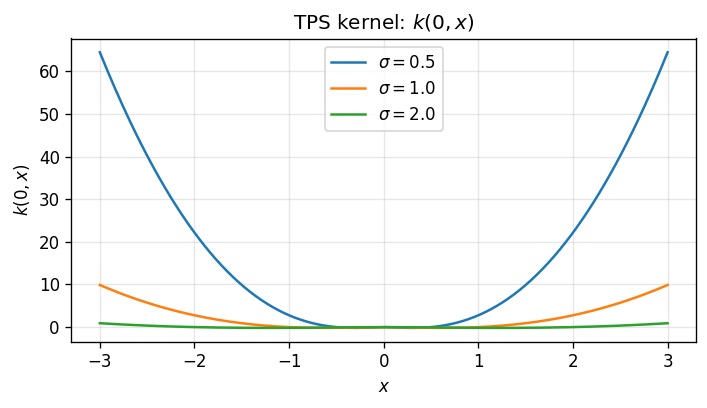

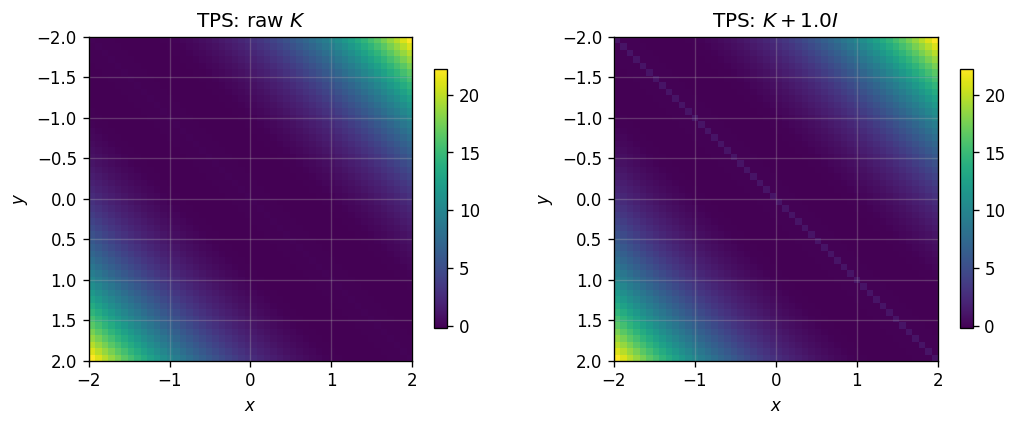

In [6]:
# TPS kernel slice: k(0, x) -> non-stationary
sigmas_tps = [0.5, 1.0, 2.0]
x = np.linspace(-3, 3, 300).reshape(-1, 1)
origin = np.zeros((1, 1))

tps_slices = {}
for s in sigmas_tps:
    sigma = np.array([s])
    K = np.asarray(compute_kernel("TPS", origin, x, sigma))
    tps_slices[rf"$\sigma = {s}$"] = K[0]

plot_slices(x.ravel(), tps_slices, "TPS kernel: $k(0, x)$")
plt.show()

# Heatmap of K + lambda*I (regularised)
x_grid = np.linspace(-2, 2, 50).reshape(-1, 1)
sigma = np.array([1.0])
K_tps = np.asarray(compute_kernel("TPS", x_grid, x_grid, sigma))
lmbda = 1.0
K_reg = K_tps + lmbda * np.eye(len(x_grid))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = axes[0].imshow(
    K_tps, extent=[x_grid[0], x_grid[-1], x_grid[-1], x_grid[0]], cmap="viridis"
)
axes[0].set_title("TPS: raw $K$")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$y$")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(
    K_reg, extent=[x_grid[0], x_grid[-1], x_grid[-1], x_grid[0]], cmap="viridis"
)
axes[1].set_title(rf"TPS: $K + {lmbda}I$")
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$y$")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## Comparisons

Side-by-side Gram matrices and eigenvalue spectra on the same point set.

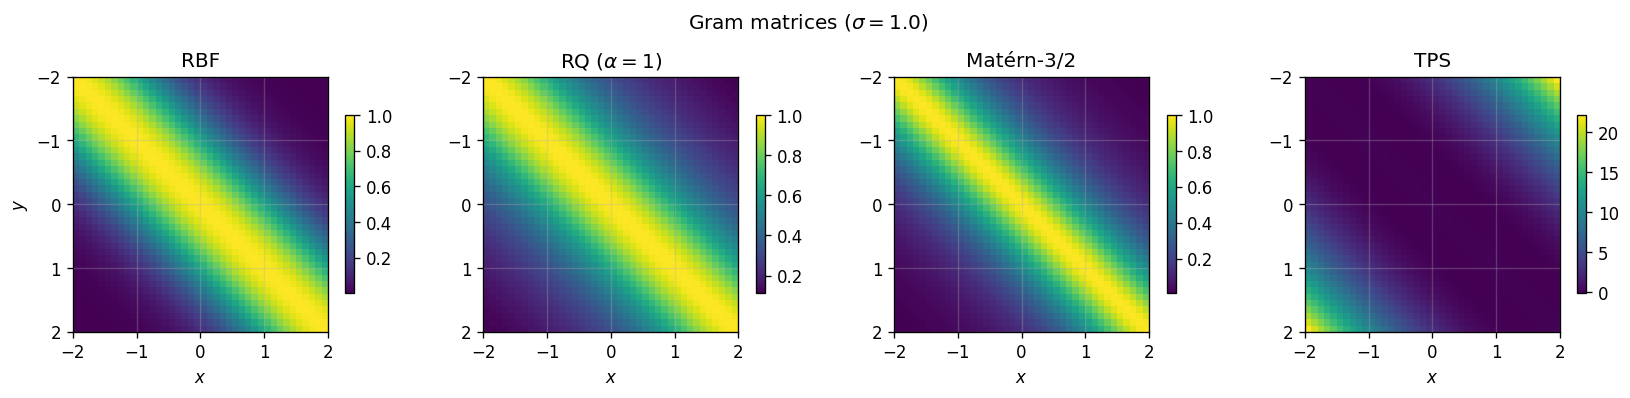

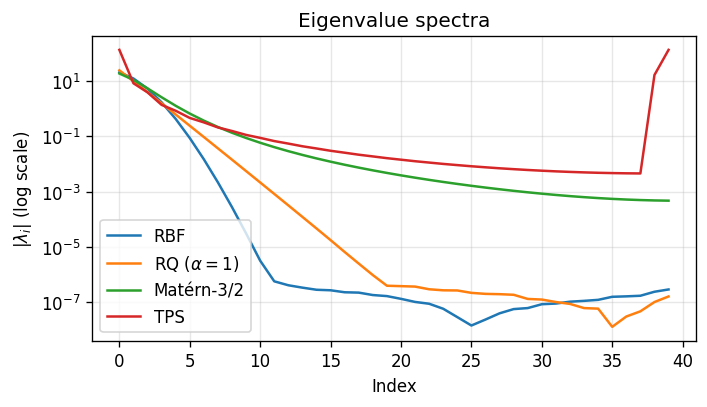

In [7]:
x_pts = np.linspace(-2, 2, 40).reshape(-1, 1)
sigma = np.array([1.0])

kernels = {
    "RBF": compute_kernel("RBF", x_pts, x_pts, sigma),
    "RQ ($\\alpha=1$)": compute_kernel("RQ", x_pts, x_pts, sigma, alpha=1.0),
    "Matérn-3/2": compute_kernel("MATERN", x_pts, x_pts, sigma, alpha=1.5),
    "TPS": compute_kernel("TPS", x_pts, x_pts, sigma),
}

# Gram matrix heatmaps
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, K) in zip(axes, kernels.items()):
    K_np = np.asarray(K)
    im = ax.imshow(K_np, extent=[-2, 2, 2, -2], cmap="viridis")
    ax.set_title(name)
    ax.set_xlabel(r"$x$")
    fig.colorbar(im, ax=ax, shrink=0.7)

axes[0].set_ylabel(r"$y$")
plt.suptitle("Gram matrices ($\\sigma = 1.0$)", y=1.02)
plt.tight_layout()
plt.show()

# Eigenvalue spectra
fig, ax = plt.subplots(figsize=(6, 3.5))
for name, K in kernels.items():
    eigs = np.sort(np.linalg.eigvalsh(np.asarray(K)))[::-1]
    ax.semilogy(np.maximum(np.abs(eigs), 1e-16), label=name, linewidth=1.5)

ax.set_xlabel("Index")
ax.set_ylabel(r"$|\lambda_i|$ (log scale)")
ax.set_title("Eigenvalue spectra")
ax.legend()
plt.tight_layout()
plt.show()

## Which kernel?

| Kernel | When to use | Caveat |
|--------|-------------|--------|
| **Matérn-5/2** | Good default. Twice differentiable, not analytically rigid | Hard to distinguish from RBF in practice |
| **Matérn-3/2** | Physical data with kinks or sharp transitions | Once-differentiable; can undersmooth genuinely smooth targets |
| **RBF** | Target is known to be very smooth (analytic) | Will oversmooth any non-analytic features |
| **RQ** | Multi-scale structure; local and global trends | Extra $\alpha$ parameter to tune |
| **TPS** | Spatial interpolation where min-curvature is the right bias | Non-stationary, only CPD, needs regularisation |

Start with Matérn-5/2. Use RBF only if you have reason to believe the target is analytic. Use RQ for multi-scale data. Use TPS for spatial smoothing where curvature minimisation is the right inductive bias.

For the full regression and fitting pipeline, see [GaussianProcesses.ipynb](GaussianProcesses.ipynb).

## Length Scale

The per-dim length scale $\sigma_d$ controls the correlation range along each axis. Below: RBF Gram matrices at different $\sigma$ values, showing the transition from near-diagonal (short range) to near-constant (long range).

/tmp/ipykernel_76985/34737232.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


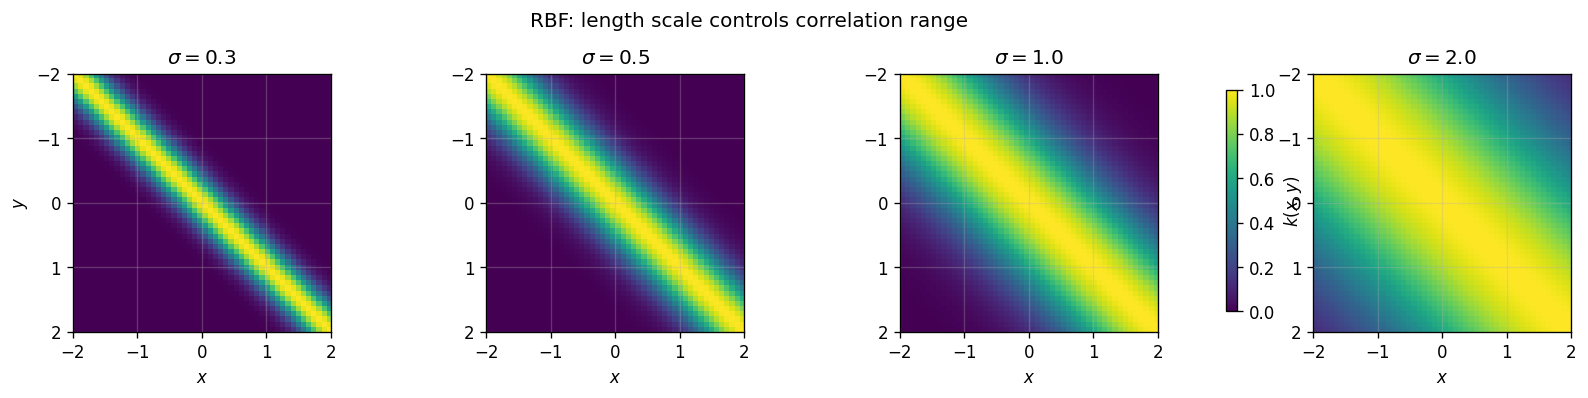

In [8]:
sigma_values = [0.3, 0.5, 1.0, 2.0]
x_pts = np.linspace(-2, 2, 50).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, s in zip(axes, sigma_values):
    sigma = np.array([s])
    K = np.asarray(compute_kernel("RBF", x_pts, x_pts, sigma))
    im = ax.imshow(K, extent=[-2, 2, 2, -2], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(rf"$\sigma = {s}$")
    ax.set_xlabel(r"$x$")

axes[0].set_ylabel(r"$y$")
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label=r"$k(x, y)$")
plt.suptitle("RBF: length scale controls correlation range", y=1.02)
plt.tight_layout()
plt.show()